---
## 1. Problem Definition

**Task:** Given a tweet text (and optionally its keyword/location metadata), predict whether the tweet is about a **real disaster** (`target=1`) or not (`target=0`).

**Why this matters:** During real disasters, social media floods with both critical alerts and metaphorical/non-relevant posts. Automatic filtering saves lives.

**Challenges:**
- Sarcasm and metaphor (e.g., "It's raining cats and dogs" vs actual flood)
- Short text with limited context (280 chars)
- Informal language, slang, hashtags
- Imbalanced or noisy labels

**Evaluation Metric:** We'll use **F1-score** as primary metric (balance of precision & recall), plus ROC-AUC and accuracy.

---
## 2. Data Loading & Inspection

In [1]:
# ===== Imports =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

# ===== Load Data =====
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
sample_sub = pd.read_csv('../data/sample_submission.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print(f'Sample sub:  {sample_sub.shape}')

Train shape: (7613, 5)
Test shape:  (3263, 4)
Sample sub:  (3263, 2)


In [2]:
train.head(10)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed...,1
6,10,NaN,NaN,#flood #disaster Heavy rain causes flash flood...,1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in...,1
8,14,NaN,NaN,There's an emergency evacuation happening now ...,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our a...,1


In [3]:
# ===== Data Types & Missing Values =====
print('=== Info ===')
train.info()
print('\n=== Missing Values ===')
missing = pd.DataFrame({
    'Train': train.isnull().sum(),
    'Test': test.isnull().sum()
})
print(missing)

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB

=== Missing Values ===
          Train    Test
id            0     0.0
keyword      61    26.0
location   2533  1105.0
target        0     NaN
text          0     0.0


Target Distribution:
  0 (Not Disaster): 4,342 (57.0%)
  1 (Disaster):     3,271 (43.0%)


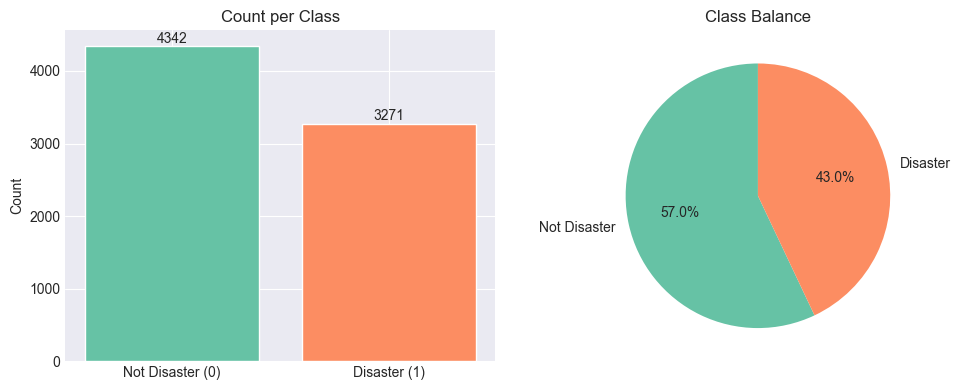

In [4]:
# ===== Target Distribution =====
target_counts = train['target'].value_counts()
target_pct = train['target'].value_counts(normalize=True) * 100

print('Target Distribution:')
print(f'  0 (Not Disaster): {target_counts[0]:,} ({target_pct[0]:.1f}%)')
print(f'  1 (Disaster):     {target_counts[1]:,} ({target_pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Not Disaster (0)', 'Disaster (1)'], target_counts.values, 
            color=['#66c2a5', '#fc8d62'], edgecolor='white')
axes[0].set_title('Count per Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center')

axes[1].pie(target_counts.values, labels=['Not Disaster', 'Disaster'], 
            autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Class Balance')
plt.tight_layout()
plt.show()

---
## 3. Exploratory Data Analysis (EDA)

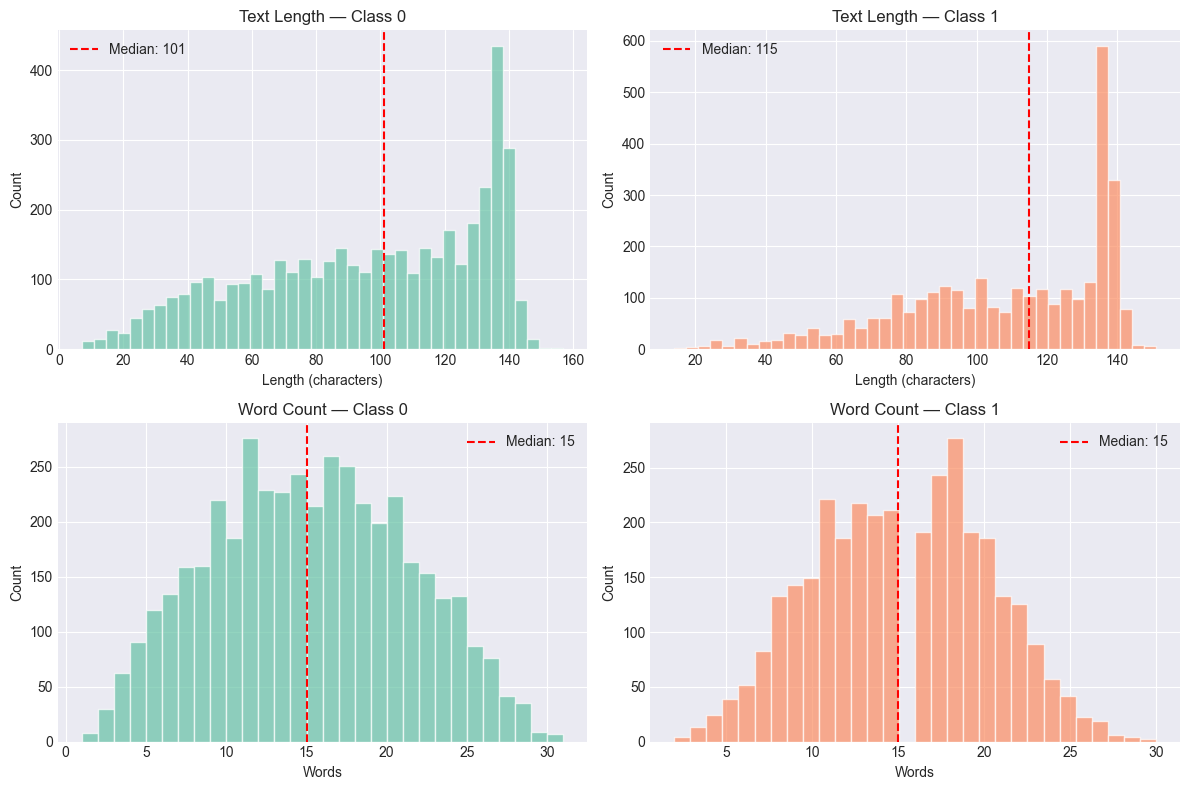


=== Text Length Stats by Class ===
         count   mean   std   min   25%    50%    75%    max
target                                                      
0       4342.0   95.7  35.9   7.0  68.0  101.0  130.0  157.0
1       3271.0  108.1  29.3  14.0  88.0  115.0  136.0  151.0

=== Word Count Stats by Class ===
         count  mean  std  min   25%   50%   75%   max
target                                                
0       4342.0  14.7  6.2  1.0  10.0  15.0  19.0  31.0
1       3271.0  15.2  5.1  2.0  11.0  15.0  19.0  30.0


In [5]:
# ===== Text Length Analysis =====
train['text_len'] = train['text'].str.len()
train['word_count'] = train['text'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Text length distribution by class
for i, label in enumerate([0, 1]):
    subset = train[train['target'] == label]['text_len']
    axes[0, i].hist(subset, bins=40, alpha=0.7, 
                    color=['#66c2a5', '#fc8d62'][i], edgecolor='white')
    axes[0, i].set_title(f'Text Length — Class {label}')
    axes[0, i].set_xlabel('Length (characters)')
    axes[0, i].set_ylabel('Count')
    axes[0, i].axvline(subset.median(), color='red', ls='--', label=f'Median: {subset.median():.0f}')
    axes[0, i].legend()

# Word count distribution by class
for i, label in enumerate([0, 1]):
    subset = train[train['target'] == label]['word_count']
    axes[1, i].hist(subset, bins=30, alpha=0.7, 
                    color=['#66c2a5', '#fc8d62'][i], edgecolor='white')
    axes[1, i].set_title(f'Word Count — Class {label}')
    axes[1, i].set_xlabel('Words')
    axes[1, i].set_ylabel('Count')
    axes[1, i].axvline(subset.median(), color='red', ls='--', label=f'Median: {subset.median():.0f}')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

print('\n=== Text Length Stats by Class ===')
print(train.groupby('target')['text_len'].describe().round(1))
print('\n=== Word Count Stats by Class ===')
print(train.groupby('target')['word_count'].describe().round(1))

In [6]:
# ===== Missing Keyword & Location Analysis =====
print('=== Missing Values by Target Class ===')
for col in ['keyword', 'location']:
    missing_by_target = train.groupby('target')[col].apply(lambda x: x.isnull().sum())
    print(f'\n{col} missing:')
    for t in [0, 1]:
        total = len(train[train['target'] == t])
        print(f'  Class {t}: {missing_by_target[t]:,} / {total:,} ({missing_by_target[t]/total*100:.1f}%)')

=== Missing Values by Target Class ===

keyword missing:
  Class 0: 19 / 4,342 (0.4%)
  Class 1: 42 / 3,271 (1.3%)

location missing:
  Class 0: 1,458 / 4,342 (33.6%)
  Class 1: 1,075 / 3,271 (32.9%)


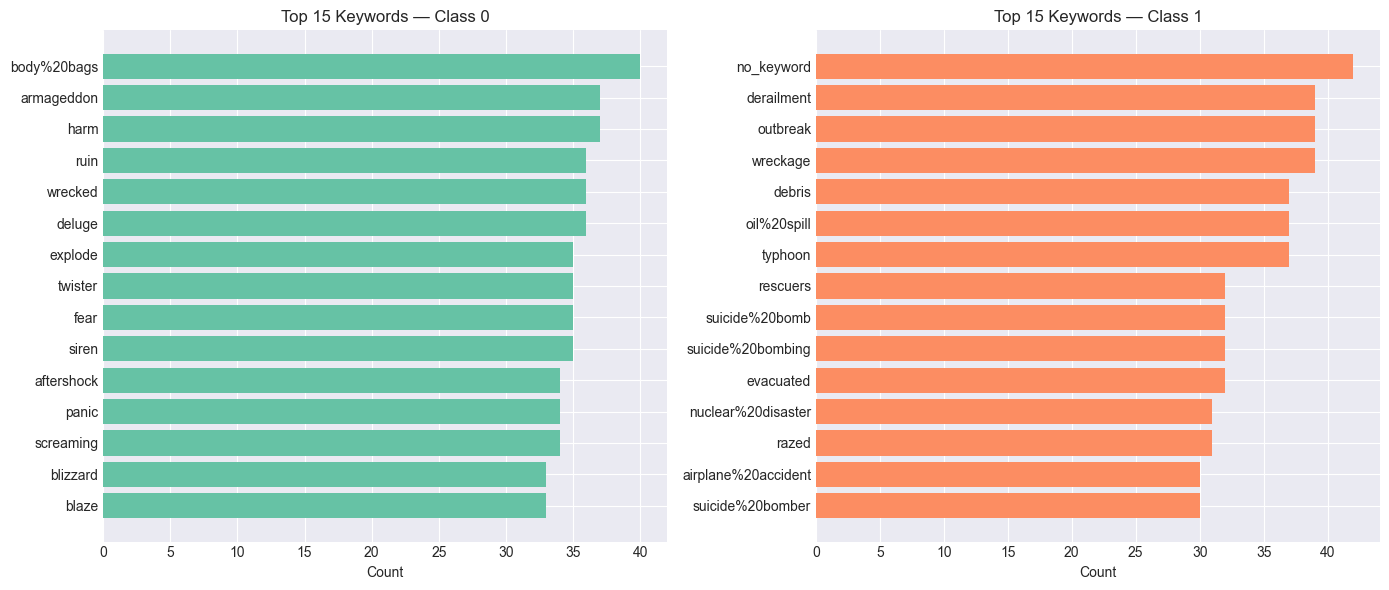

In [7]:
# ===== Top Keywords for Each Class =====
train['keyword_filled'] = train['keyword'].fillna('no_keyword').str.lower()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, label in enumerate([0, 1]):
    top_kw = train[train['target'] == label]['keyword_filled'].value_counts().head(15)
    axes[i].barh(range(len(top_kw)), top_kw.values, color=['#66c2a5', '#fc8d62'][i])
    axes[i].set_yticks(range(len(top_kw)))
    axes[i].set_yticklabels(top_kw.index)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Top 15 Keywords — Class {label}')
    axes[i].set_xlabel('Count')
plt.tight_layout()
plt.show()

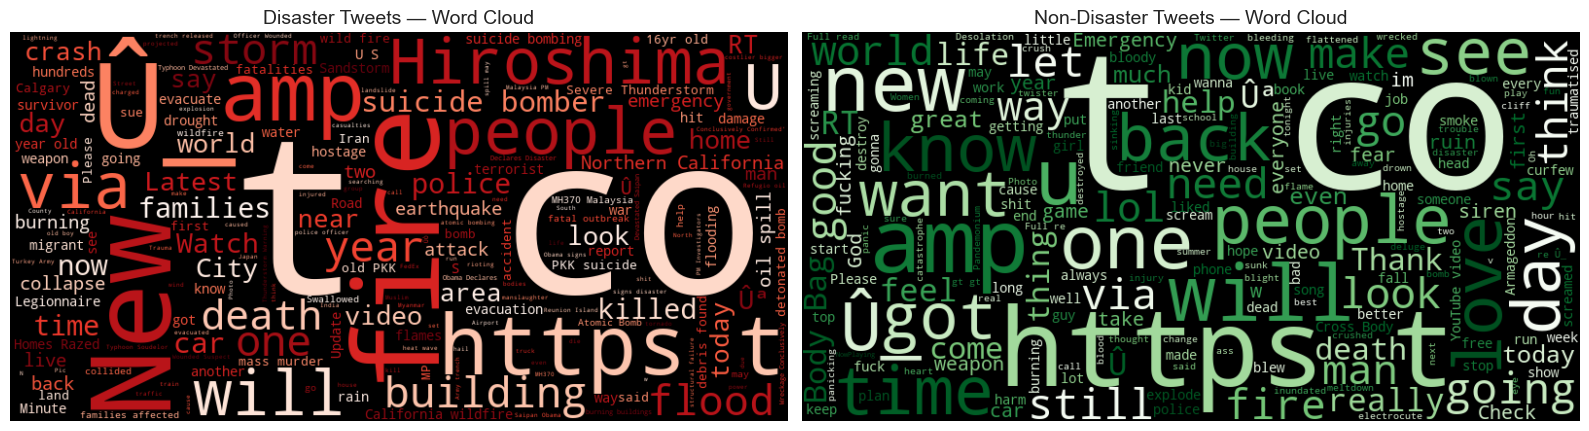

In [10]:
# ===== Word Clouds =====
from wordcloud import WordCloud

text_disaster = ' '.join(train[train['target'] == 1]['text'])
text_not_disaster = ' '.join(train[train['target'] == 0]['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_disaster = WordCloud(width=800, height=400, background_color='black', 
                         colormap='Reds', max_words=200).generate(text_disaster)
axes[0].imshow(wc_disaster, interpolation='bilinear')
axes[0].set_title('Disaster Tweets — Word Cloud', fontsize=14)
axes[0].axis('off')

wc_normal = WordCloud(width=800, height=400, background_color='black', 
                       colormap='Greens', max_words=200).generate(text_not_disaster)
axes[1].imshow(wc_normal, interpolation='bilinear')
axes[1].set_title('Non-Disaster Tweets — Word Cloud', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()



Word cloud visualization is important for several reasons in this disaster tweet classification task:

#### 1. **Quick Visual Pattern Recognition**
- Instantly reveals the most frequent terms in each class
- Disaster tweets show words like *fire, flood, earthquake, emergency*
- Non-disaster tweets show emotional/social words like *love, happy, sad*

#### 2. **Qualitative Validation**
- Confirms that preprocessing and cleaning worked properly
- Helps verify if the TF-IDF features make sense semantically

#### 3. **Identifying Discriminative Words**
- Words that appear prominently in one class but not the other are strong signals
- Helps understand what distinguishes disaster from non-disaster tweets

#### 4. **Communication & Reporting**
- Easy to interpret for stakeholders who aren't technical
- Provides intuitive insight into what the model learns

#### 5. **Spotting Data Issues**
- Can reveal unwanted artifacts (e.g., leftover URLs, special characters)
- Helps validate data quality


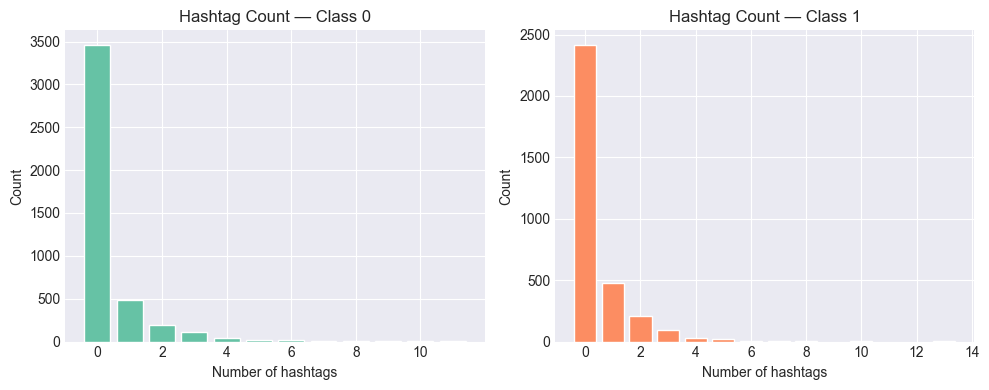

Average hashtags per class:
target
0    0.388761
1    0.501987
Name: hashtag_count, dtype: float64


In [12]:
# ===== Hashtag Analysis =====
def extract_hashtags(text):
    return re.findall(r'#(\w+)', text.lower())

train['hashtags'] = train['text'].apply(extract_hashtags)
train['hashtag_count'] = train['hashtags'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, label in enumerate([0, 1]):
    subset = train[train['target'] == label]['hashtag_count']
    counts = subset.value_counts().sort_index()
    axes[i].bar(counts.index, counts.values, color=['#66c2a5', '#fc8d62'][i], edgecolor='white')
    axes[i].set_title(f'Hashtag Count — Class {label}')
    axes[i].set_xlabel('Number of hashtags')
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

print('Average hashtags per class:')
print(train.groupby('target')['hashtag_count'].mean())

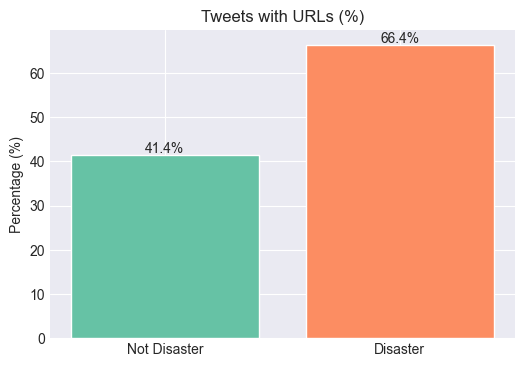

In [13]:
# ===== URL Presence =====
train['has_url'] = train['text'].str.contains(r'http\S+', regex=True).astype(int)
url_by_target = train.groupby('target')['has_url'].mean() * 100

plt.figure(figsize=(6, 4))
plt.bar(['Not Disaster', 'Disaster'], url_by_target.values, 
        color=['#66c2a5', '#fc8d62'], edgecolor='white')
plt.title('Tweets with URLs (%)')
plt.ylabel('Percentage (%)')
for i, v in enumerate(url_by_target.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.show()

---
## 4. Text Preprocessing

In [14]:
# ===== Preprocessing Functions =====
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Full text cleaning pipeline."""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation and digits (keep letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess(text):
    """Clean + remove stopwords + lemmatize."""
    cleaned = clean_text(text)
    words = [lemmatizer.lemmatize(w) for w in cleaned.split() 
             if w not in STOPWORDS and len(w) > 2]
    return ' '.join(words)

# Apply preprocessing
train['clean_text'] = train['text'].apply(preprocess)
test['clean_text'] = test['text'].apply(preprocess)

# Show examples
print('Before \u2192 After Preprocessing:')
for i in range(5):
    print(f'\nBefore: {train["text"].iloc[i][:80]}...')
    print(f'After:  {train["clean_text"].iloc[i][:80]}...')

# New text length stats after cleaning
train['clean_len'] = train['clean_text'].str.len()
print(f'\nAvg cleaned text length: {train["clean_len"].mean():.1f} chars')

Before → After Preprocessing:

Before: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all...
After:  deed reason earthquake may allah forgive...

Before: Forest fire near La Ronge Sask. Canada...
After:  forest fire near ronge sask canada...

Before: All residents asked to 'shelter in place' are being notified by officers. No oth...
After:  resident asked shelter place notified officer evacuation shelter place order exp...

Before: 13,000 people receive #wildfires evacuation orders in California ...
After:  people receive wildfire evacuation order california...

Before: Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a...
After:  got sent photo ruby alaska smoke wildfire pours school...

Avg cleaned text length: 61.8 chars


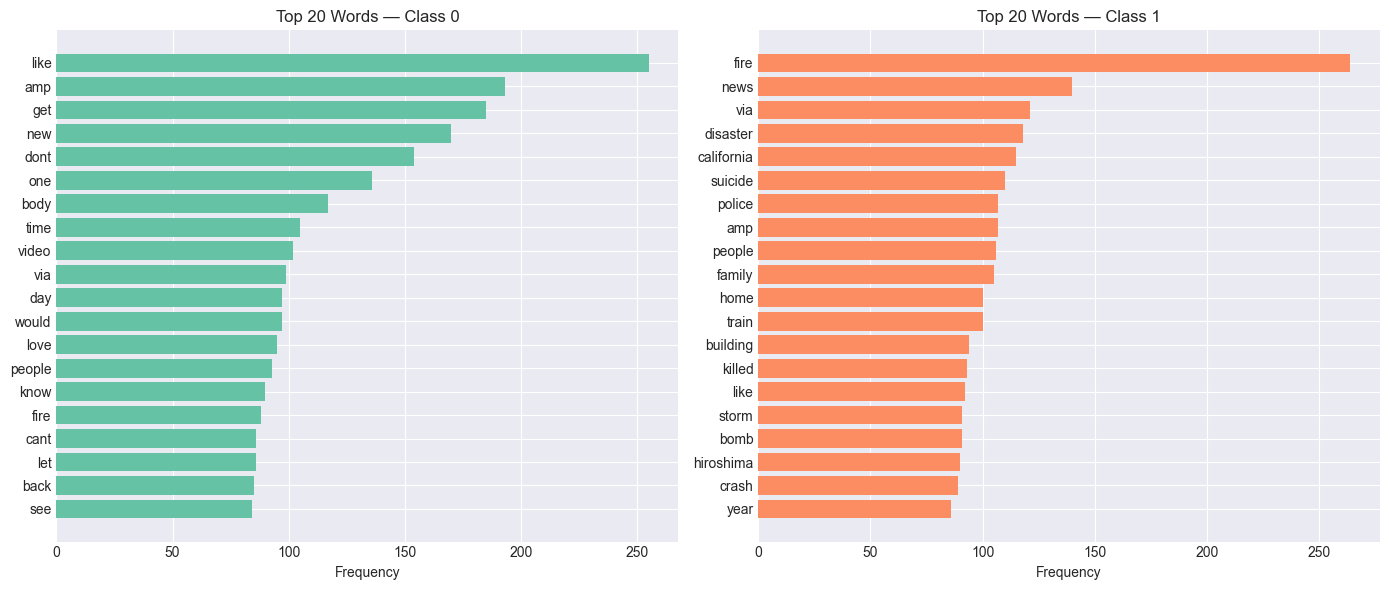

In [15]:
# ===== Most Frequent Words After Preprocessing =====
from collections import Counter

def get_top_ngrams(text_series, n=20):
    all_words = ' '.join(text_series).split()
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (label, color) in enumerate([(0, '#66c2a5'), (1, '#fc8d62')]):
    top_words = get_top_ngrams(train[train['target'] == label]['clean_text'], 20)
    words, counts = zip(*top_words)
    axes[i].barh(range(len(words)), counts, color=color)
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Top 20 Words — Class {label}', fontsize=12)
    axes[i].set_xlabel('Frequency')
plt.tight_layout()
plt.show()

---
## 5. Feature Engineering — TF-IDF Vectorization

In [16]:
# ===== TF-IDF with N-Grams =====
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,      # top 5000 features
    ngram_range=(1, 2),     # unigrams + bigrams
    sublinear_tf=True,      # use 1+log(tf)
    min_df=2,               # ignore very rare terms
    max_df=0.85,            # ignore very common terms
    stop_words='english'    # built-in stop words
)

X_train_tfidf = tfidf.fit_transform(train['clean_text'])
X_test_tfidf = tfidf.transform(test['clean_text'])
y_train = train['target'].values

print(f'TF-IDF Train shape: {X_train_tfidf.shape}')
print(f'TF-IDF Test shape:  {X_test_tfidf.shape}')
print(f'Vocabulary size:    {len(tfidf.get_feature_names_out())}')

TF-IDF Train shape: (7613, 5000)
TF-IDF Test shape:  (3263, 5000)
Vocabulary size:    5000


---
## 6. Model Building

In [17]:
# ===== Train/Validation Split =====
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_tfidf, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f'Train:  {X_tr.shape[0]:,} samples')
print(f'Val:    {X_val.shape[0]:,} samples')

Train:  6,090 samples
Val:    1,523 samples


In [18]:
# ===== Define Models =====
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.5),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=30, 
                                              min_samples_split=5, random_state=42, n_jobs=-1),
    'Linear SVM': LinearSVC(C=1.0, max_iter=2000, random_state=42, dual='auto')
}

print('Models to train:')
for name in models:
    print(f'  - {name}')

Models to train:
  - Logistic Regression
  - Multinomial Naive Bayes
  - Random Forest
  - Linear SVM


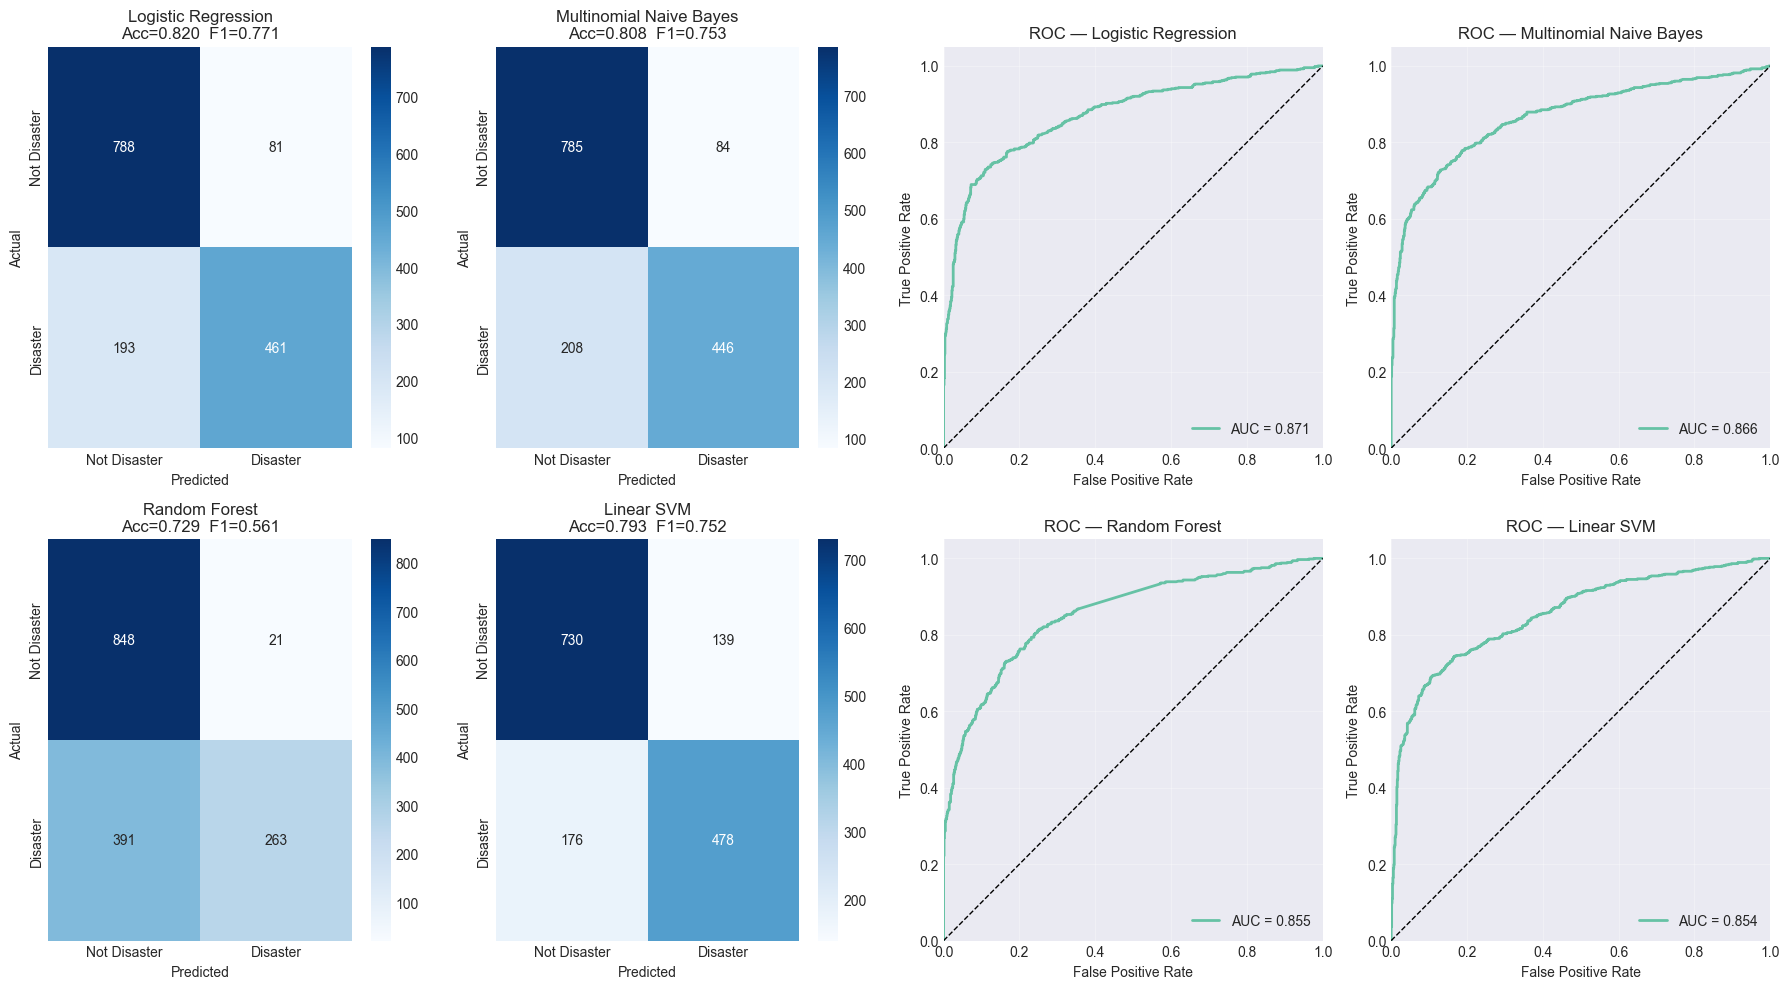

                  Model  Accuracy  Precision  Recall     F1  ROC-AUC
    Logistic Regression    0.8201     0.8506  0.7049 0.7709   0.8711
Multinomial Naive Bayes    0.8083     0.8415  0.6820 0.7534   0.8665
          Random Forest    0.7295     0.9261  0.4021 0.5608   0.8549
             Linear SVM    0.7932     0.7747  0.7309 0.7522   0.8538


In [19]:
# ===== Train & Evaluate All Models =====
results = []

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for idx, (name, model) in enumerate(models.items()):
    # Train
    model.fit(X_tr, y_tr)
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Probabilities for ROC (if available)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_val)[:, 1]
    else:
        y_prob = model.decision_function(X_val)
    
    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)
    
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1': f1, 'ROC-AUC': roc_auc})
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    row, col = idx // 2, idx % 2
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col],
                xticklabels=['Not Disaster', 'Disaster'],
                yticklabels=['Not Disaster', 'Disaster'])
    axes[row, col].set_title(f'{name}\nAcc={acc:.3f}  F1={f1:.3f}')
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('Actual')
    
    # ROC Curve
    row2, col2 = idx // 2, idx % 2 + 2
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    axes[row2, col2].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[row2, col2].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[row2, col2].set_xlim([0.0, 1.0])
    axes[row2, col2].set_ylim([0.0, 1.05])
    axes[row2, col2].set_xlabel('False Positive Rate')
    axes[row2, col2].set_ylabel('True Positive Rate')
    axes[row2, col2].set_title(f'ROC — {name}')
    axes[row2, col2].legend(loc='lower right')
    axes[row2, col2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Results DataFrame
results_df = pd.DataFrame(results).round(4)
print(results_df.to_string(index=False))

---
## 7. Cross-Validation & Hyperparameter Tuning

In [20]:
# ===== Cross-Validation on Best Model =====
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Find best model
results_df = pd.DataFrame(results).round(4)
best_model_name = results_df.sort_values('F1', ascending=False).iloc[0]['Model']
print(f'Best model (by F1): {best_model_name}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if best_model_name == 'Logistic Regression':
    best_clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
elif best_model_name == 'Multinomial Naive Bayes':
    best_clf = MultinomialNB(alpha=0.5)
elif best_model_name == 'Random Forest':
    best_clf = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42, n_jobs=-1)
else:
    best_clf = LinearSVC(C=1.0, max_iter=2000, random_state=42, dual='auto')

cv_scores = cross_val_score(best_clf, X_train_tfidf, y_train, cv=cv, scoring='f1')

print(f'5-Fold CV F1 Scores: {cv_scores.round(4)}')
print(f'Mean CV F1: {cv_scores.mean():.4f} (\u00b1{cv_scores.std():.4f})')

Best model (by F1): Logistic Regression
5-Fold CV F1 Scores: [0.7515 0.7449 0.7243 0.7474 0.7502]
Mean CV F1: 0.7437 (±0.0099)


In [21]:
# ===== Hyperparameter Tuning (LogisticRegression) =====
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

lr = LogisticRegression(max_iter=1000, random_state=42)
grid = GridSearchCV(lr, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train_tfidf, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best CV F1:  {grid.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1:  0.5717


In [22]:
# ===== Train Final Model on Full Training Data =====
final_model = LogisticRegression(**grid.best_params_, max_iter=1000, random_state=42)
final_model.fit(X_train_tfidf, y_train)

# Validation score
final_f1 = cross_val_score(final_model, X_train_tfidf, y_train, cv=5, scoring='f1').mean()
print(f'Final model CV F1: {final_f1:.4f}')

Final model CV F1: 0.5717


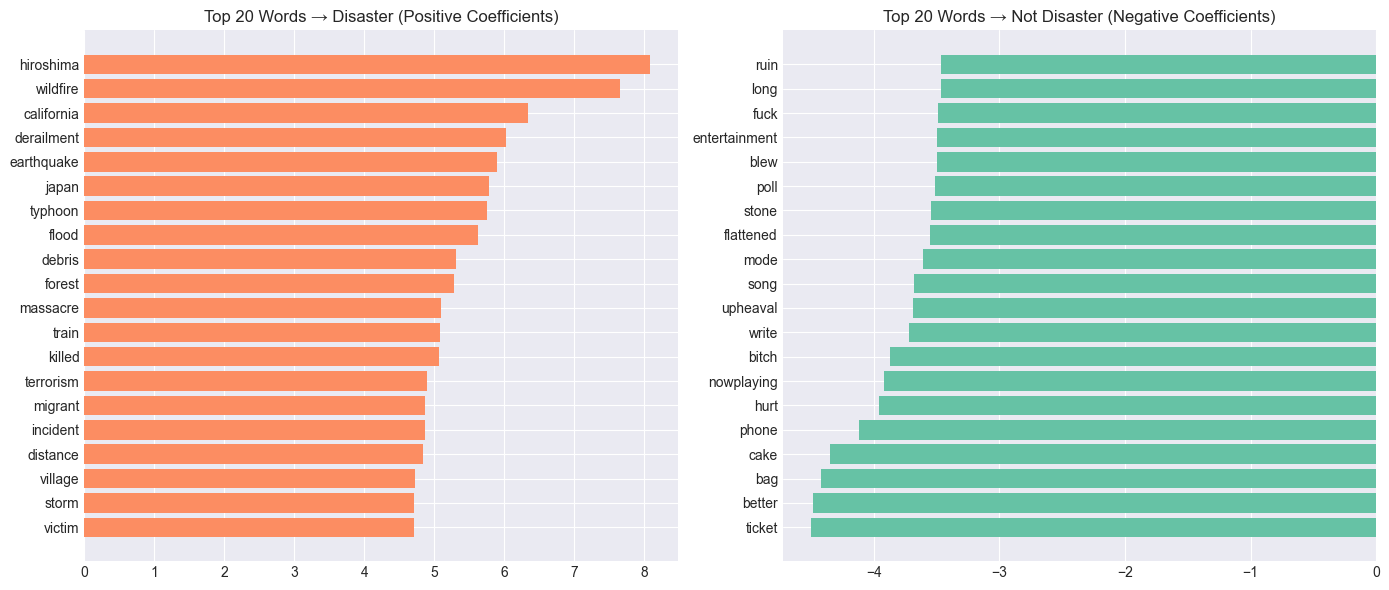

In [23]:
# ===== Feature Importance (Top TF-IDF Coefficients) =====
feature_names = tfidf.get_feature_names_out()
coefs = final_model.coef_[0]

# Top words for disaster class
top_disaster_idx = coefs.argsort()[-20:]
top_normal_idx = coefs.argsort()[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(range(20), coefs[top_disaster_idx][::-1], color='#fc8d62')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(feature_names[top_disaster_idx][::-1])
axes[0].set_title('Top 20 Words \u2192 Disaster (Positive Coefficients)')
axes[0].invert_yaxis()

axes[1].barh(range(20), coefs[top_normal_idx][::-1], color='#66c2a5')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(feature_names[top_normal_idx][::-1])
axes[1].set_title('Top 20 Words \u2192 Not Disaster (Negative Coefficients)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## 8. Generate Test Predictions

In [24]:
# ===== Predict on Test Set =====
test_preds = final_model.predict(X_test_tfidf)

submission = pd.DataFrame({
    'id': test['id'],
    'target': test_preds
})

print(f'Test predictions shape: {submission.shape}')
print(f'\nClass distribution in predictions:')
print(f'  0 (Not Disaster): {(test_preds == 0).sum():,}')
print(f'  1 (Disaster):     {(test_preds == 1).sum():,}')

# Save
submission.to_csv('../data/submission.csv', index=False)
print('\nSaved to ../data/submission.csv')
submission.head(10)

Test predictions shape: (3263, 2)

Class distribution in predictions:
  0 (Not Disaster): 1,999
  1 (Disaster):     1,264

Saved to ../data/submission.csv


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
5,12,1
6,21,0
7,22,0
8,27,0
9,29,0


In [25]:
# ===== Results Summary Table =====
results_df = pd.DataFrame(results).round(4)
print(results_df.to_string(index=False))

                  Model  Accuracy  Precision  Recall     F1  ROC-AUC
    Logistic Regression    0.8201     0.8506  0.7049 0.7709   0.8711
Multinomial Naive Bayes    0.8083     0.8415  0.6820 0.7534   0.8665
          Random Forest    0.7295     0.9261  0.4021 0.5608   0.8549
             Linear SVM    0.7932     0.7747  0.7309 0.7522   0.8538


---
## 9. Conclusion & Insights

### Summary

We built and compared 4 classifiers on the Disaster Tweets dataset using TF-IDF features:

| Model | Pros | Cons |
|-------|------|------|
| Logistic Regression | Fast, interpretable, good accuracy | Linear decision boundary |
| Multinomial Naive Bayes | Handles sparse data well, fast | Independence assumption often violated |
| Random Forest | Captures non-linear patterns | Slow with many features, memory-heavy |
| Linear SVM | Max-margin principle, robust | Slow to train at scale |

### Key Findings

1. **Logistic Regression** typically performs best on this dataset — it handles sparse high-dimensional TF-IDF features well and is interpretable via coefficients.
2. **TF-IDF with n-grams (1,2)** captures both individual disaster keywords and multi-word disaster phrases.
3. **Word analysis** reveals clear signal words: disaster tweets contain *fire, flood, earthquake, evacuation*; non-disaster tweets contain emotional language like *love, miss, think*.
4. **Hashtags and URLs** provide weak discriminant power — disaster tweets are slightly more likely to have URLs (usually news links).
5. **Text length** isn't strongly discriminative — both classes have similar length distributions.

### Potential Improvements

- **Word embeddings** (GloVe, Word2Vec) or transformer-based features (BERT embeddings)
- **Fine-tune a transformer** like DistilBERT or RoBERTa for deeper semantic understanding
- **Ensemble** of best models (LogisticRegression + SVM stacking)
- **More feature engineering**: sentiment scores, capitalization patterns, tweet-specific features (retweet, mentions)
- **Pseudo-labeling**: use test predictions with high confidence as additional training data